Load all the libraries that are being used.

In [1]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Load data from AirtrafficA4.csv files and prepare input and output variables

In [2]:
#load dataset
data = pd.read_csv('AirtrafficA4.csv')
year = data['YEAR']
month = data['MONTH']
monthmap = {'JAN':0,'FEB':1,'MAR':2,'APR':3,'MAY':4,'JUNE':5,'JULY':6,'AUG':7,'SEP':8,'OCT':9,'NOV':10,'DEC':11}
passengercounts = data['PASSENGERS CARRIED'].to_numpy()
i=0
time=[]
while i < 128:
    passengercounts[i]=str(str(passengercounts[i]).replace(",",""))
    if passengercounts[i]=='nan':
        passengercounts[i]='0'
    passengercounts[i]=int(passengercounts[i])
    time.append(year[i]*12+monthmap[month[i].replace(" ","")])
    i=i+1
# Combine data and time into tuples, then sort by time
weighted_data = sorted(zip(passengercounts, time), key=lambda x: x[1])

# Extract sorted data according to time
passengercounts = [item[0] for item in weighted_data]
passengercount=pd.Series(passengercounts)
time = [item[1] for item in weighted_data]

# Taking d=1 for arima
passengercount_diff = passengercount.diff().dropna()


FileNotFoundError: [Errno 2] No such file or directory: 'AirtrafficA4.csv'

Implementing ARIMA model with (1,1,1) to predict 12 future values

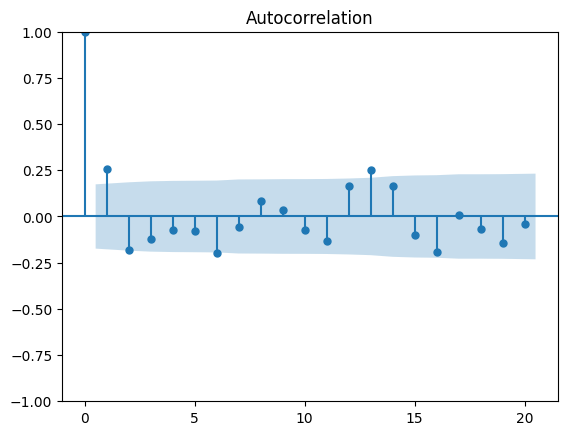

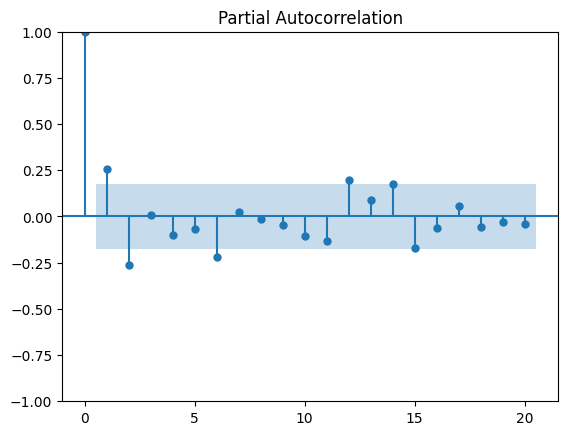

In [8]:
# function for ar part
def fit_ar(y, p):
    X = np.column_stack([y.shift(i) for i in range(1, p + 1)])
    X = np.nan_to_num(X)
    beta = np.linalg.lstsq(X, y.values, rcond=None)[0]
    return beta

# function for ma part
def fit_ma(y, residuals, q):
    X = np.column_stack([residuals.shift(i) for i in range(1, q + 1)])
    X = np.nan_to_num(X)
    theta = np.linalg.lstsq(X, residuals.values, rcond=None)[0]
    return theta

# Implementing arima
def forecast_arima(y, beta_ar, theta_ma, residuals, steps):
    y_forecast = list(y[-max(p,q):])
    residuals_forecast = list(residuals[-max(p,q):])
    for _ in range(steps):
        ar_part = sum(beta_ar[i] * y_forecast[-(i + 1)] for i in range(len(beta_ar)))
        ma_part = sum(theta_ma[i] * residuals_forecast[-(i + 1)] for i in range(len(theta_ma)))
        new_value = ar_part + ma_part
        y_forecast.append(new_value)
        residuals_forecast.append(new_value - (ar_part + ma_part))  # Update residuals
    return np.array(y_forecast)

plot_acf(passengercount_diff, lags=20)
plt.show()

plot_pacf(passengercount_diff, lags=20)
plt.show()

# Found best possible p,q as p=1 and q=1 from graph of acf, pacf functions 
p = 1
q = 1
beta_ar = fit_ar(passengercount_diff, p)

# Calculate residuals for fitting MA model
residuals = passengercount_diff.iloc[p:] - sum(passengercount_diff.shift(i).iloc[p:] * beta_ar[i - 1] for i in range(1, p + 1))
residuals = residuals.dropna()

theta_ma = fit_ma(passengercount_diff, residuals, q)

# Evaluate ARIMA model
forecast = forecast_arima(passengercount_diff, beta_ar, theta_ma, residuals, 12)
forecast = np.cumsum(forecast)  # Reverse differencing to get actual values
forecast = passengercount.iloc[-1] + forecast
forecast=forecast[-12:]

Creating a submission.csv file to store predictions.

In [9]:
# CSV file name
filename = 'submission.csv'

Month = ['2023 SEP','2023 OCT','2023 NOV','2023 DEC','2024 JAN','2024 FEB','2024 MAR','2024 APR','2024 MAY','2024 JUN','2024 JUL','2024 AUG']
# Write to CSV file
with open(filename, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(['YEAR_MONTH', 'PASSENGERS CARRIED'])  # Writing header
    for i, count in enumerate(forecast, start=0):
        csvwriter.writerow([f'{Month[i]}', count])
